"""
Name: AqFood_Supply_Chain_Analyzer.py
Project: Aqueduct Food Tool Supply Chain Analyzer 2026
Description:
  This script reads in a user's supply chain (as coordinates, states, or
  country names) and returns a list of the watersheds or aquifers the user
  operates in along with the associates Aqueduct and SBTN data. 
Created: May 2026
Author: Liz Saccoccia(elizabeth.saccoccia@wri.org). Adapted by Carlos 
Original script: 
http://github.com/resource-watch/aqueduct-analysis-microservice/blob/dev/aqueduct/services/food_supply_chain_service.py 
"""

In [10]:
#imports
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import warnings
import numpy as np
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [12]:
#import files
df_aq = gpd.read_file('aq_data_supplychain.geojson', encoding="utf-8-sig")
#add in SBTN Data - this will be updated
SBTN = pd.read_csv('SBTN_SON_V2.csv')
#import production by pfaf
prod = pd.read_csv('all_crops_pfaf_melt.csv')

In [146]:
# Define whether location will use point + radius, state, or country to
# select watersheds
def find_selection_type(row):
    """
    :param row: individual row
    :return: location type (point, state, country, none)
    """
    # If coordiantes exist, location type is point
    if isinstance(row["Latitude"], float) and np.isnan(row["Latitude"]) == False:
        select_by = "point"
    # If state exists WITH country name, location type is state
    elif (isinstance(row["State"], str) == True) & (isinstance(row["Country"], str) == True):
        select_by = "state"
    # If neither of those are true, and a country name exists, location type is country
    elif isinstance(row["Country"], str) == True:
        select_by = "country"
    # Else, no location type given. These will be dropped from the analysis
    else:
        select_by = np.nan
    return select_by
        
# Clean up Radius buffer values. Remove 0's, convert to decimal degrees
# (units of the analysis)
def clean_buffer(row):
    """
    :param row: individual row (1 coordinate + material type)
    :return: buffer radius in decimal degrees
    """
    val = row.Radius  # Find the radius value
    unit = str(row["Radius Units"]).lower()  # Find the radius units
    try:
        float_val = float(val)  # Turn value to floast
        if float_val == 0.0:  # If radius is 0, set to NA
            new_val = np.nan
        elif unit in [
            "miles",
            "mile",]:  
            # If units are in miles, convert to KM (multiple by 1.609), then to degrees (divide by 111)
            new_val = float_val * 1.609 / 111.0
        elif unit in [
            "m",
            "met",
            "meter",
            "meters",
        ]:  # If units are in meters, convert to KM then to degrees (divide by 111)
            new_val = (float_val / 1000) / 111.0
        elif unit in [
            "km",
            "kilometer",
            "kilometers",
        ]:  # If units are in kilometers, convert to degrees (divide by 111)
            new_val = float_val / 111.0
        else:  # Else, return Null radius, report as error
            new_val = np.nan
    except:
        new_val = np.nan
    return new_val
    
# Create buffer (in decimal degrees) around point
def buffer(row):
    """
    :param row: individual row (1 coordinate + material type)
    :return: circle polygon
    """
    return row.geometry.buffer(row.Buffer)

In [147]:
#User input variables

#these need to change based on users data
#Lat/Longs
# Latitude =  #required

# Longitude =  #required

# Radius =  #optional

# Crop =  #required

# Irrigation =  #required

# Volume =  #optional

# #Country + State

# Country = #required

# State =  #optional

# Irrigation = #required

# Volume = #optional



In [148]:
# or table input
df = pd.read_excel('AqueductFood_SupplyChain_Input_Template_All_Data_Levels.xlsm', sheet_name = 'data_entry',skiprows=1)
df = df.reset_index()
df = df.replace("Unknown", "All")
df = df.rename(columns={'index':'UniqueID'})
print('data file imported')
df

data file imported


,UniqueID,Business Unit,Latitude,Longitude,Radius,Radius Units,Country,iso_code,State,Commodity,commodity_code,Total Volume,Volume Units,Irrigation
0,0,North America Snacks,38.898992,-77.007986,500.0,kilometer,NaN,NaN,NaN,Maize,MAIZ,450,metric tons,Rainfed
1,1,EU Snacks,-23.568232,-46.693983,200.0,kilometer,NaN,NaN,NaN,Wheat,WHEA,100,kilograms,Both
2,2,North America Snacks,NaN,NaN,NaN,NaN,United States,USA,California,Maize,MAIZ,500,NaN,Irrigated
3,3,South America Snacks,NaN,NaN,NaN,NaN,Argentina,ARG,NaN,Soybean,SOYB,1000,metric tons,All


In [149]:
 # FIND LOCATIONS BASED ON WATER UNIT
            # ----------------------------------
            # Categorize location type
df["Select_By"] = df.apply(lambda x: find_selection_type(x), axis=1)
df

,UniqueID,Business Unit,Latitude,Longitude,Radius,Radius Units,Country,iso_code,State,Commodity,commodity_code,Total Volume,Volume Units,Irrigation,Select_By
0,0,North America Snacks,38.898992,-77.007986,500.0,kilometer,NaN,NaN,NaN,Maize,MAIZ,450,metric tons,Rainfed,point
1,1,EU Snacks,-23.568232,-46.693983,200.0,kilometer,NaN,NaN,NaN,Wheat,WHEA,100,kilograms,Both,point
2,2,North America Snacks,NaN,NaN,NaN,NaN,United States,USA,California,Maize,MAIZ,500,NaN,Irrigated,state
3,3,South America Snacks,NaN,NaN,NaN,NaN,Argentina,ARG,NaN,Soybean,SOYB,1000,metric tons,All,country


In [150]:
#Step 1. Add data and create buffer for points
# SELECT POINT LOCATIONS
df_points = df[df["Select_By"] == "point"]
print("There are {} points".format(len(df_points)))

df_points = df[df['Latitude'].notna()]
# select lat long
# Make sure coordinates are floats. Drop rows where encoding fails
df_points["Latitude"] = pd.to_numeric(df_points["Latitude"], errors="coerce")  # Make sure latitudes are floats
df_points["Longitude"] = pd.to_numeric(df_points["Longitude"], errors="coerce")  # Make sure latitudes are floats

# Create XY from coordinates
df_points["geometry"] = df_points.apply(lambda row: Point(float(row.Longitude), row.Latitude), axis=1)
df_points_check = df_points

# Convert Radius into decimal degree value
df_points["Radius"] = df_points.apply(lambda x: clean_buffer(x), axis=1)

buffered = df_points.filter(["Radius", "geometry", "UniqueID"])
buffered["geometry"] = buffered.apply(lambda x: x.geometry.buffer(x.Radius), axis=1)
buffered = gpd.GeoDataFrame(buffered, geometry=buffered.geometry)
print("The points buffer is complete")
buffered

There are 2 points
The points buffer is complete


,Radius,geometry,UniqueID
0,4.504505,"POLYGON ((-72.50348 38.89899, -72.52517 38.457...",0
1,1.801802,"POLYGON ((-44.89218 -23.56823, -44.90086 -23.7...",1


In [151]:
df_points = df_points.drop(columns='geometry')
df_points_buff = df_points.merge(buffered, on = 'UniqueID')

In [152]:
df_points_buff = gpd.GeoDataFrame(df_points_buff , crs="EPSG:4326")

In [153]:
df_aq["aq_geometry"] = df_aq["geometry"]
df_aq
df_points_aq = gpd.sjoin(df_points_buff, df_aq, how="left", op="intersects")
df_points_aq = df_points_aq.set_geometry("aq_geometry")
df_points_aq = df_points_aq.drop(columns={'geometry'})
df_points_aq = df_points_aq.rename(columns={'aq_geometry':'geometry'})
df_points_aq = df_points_aq.set_geometry("geometry", crs="EPSG:4326")
df_points_aq

,UniqueID,Business Unit,Latitude,Longitude,Radius_x,Radius Units,Country_left,iso_code_left,State_left,Commodity,commodity_code,Total Volume,Volume Units,Irrigation,Select_By,Radius_y,index_right,string_id,aq30_id,Shape_Leng,string_id_1,aq30_id_1,pfaf_id,gid_1,aqid,iso_code_right,Country_right,State_right,area_km2,bws_raw,bws_score,bws_cat,bws_label,bwd_raw,bwd_score,bwd_cat,bwd_label,iav_raw,iav_score,iav_cat,iav_label,sev_raw,sev_score,sev_cat,sev_label,cep_raw,cep_score,cep_cat,cep_label,geometry
0,0,North America Snacks,38.898992,-77.007986,4.504505,kilometer,NaN,NaN,NaN,Maize,MAIZ,450,metric tons,Rainfed,point,4.504505,53836,732170-USA.34_1-None,53839.0,13.367010,732170-USA.34_1-None,53839,732170,USA.34_1,-9999,USA,United States,North Carolina,498.124500,0.274399,2.456276,2.0,Medium - High (20-40%),0.061520,1.057598,1.0,Low - Medium (5-25%),0.402840,1.611359,1.0,Low - Medium (0.25-0.50),0.099995,0.299986,0.0,Low (<0.33),-1.297788,1.740442,1.0,Low - Medium (-5 to 0),"MULTIPOLYGON (((-76.70509 34.72491, -76.69658 ..."
0,0,North America Snacks,38.898992,-77.007986,4.504505,kilometer,NaN,NaN,NaN,Maize,MAIZ,450,metric tons,Rainfed,point,4.504505,53833,732170-USA.34_1-1400,53836.0,4.425117,732170-USA.34_1-1400,53836,732170,USA.34_1,1400,USA,United States,North Carolina,1884.855975,0.274399,2.456276,2.0,Medium - High (20-40%),0.061520,1.057598,1.0,Low - Medium (5-25%),0.402840,1.611359,1.0,Low - Medium (0.25-0.50),0.099995,0.299986,0.0,Low (<0.33),-1.297788,1.740442,1.0,Low - Medium (-5 to 0),"MULTIPOLYGON (((-76.48753 35.03552, -76.48220 ..."
0,0,North America Snacks,38.898992,-77.007986,4.504505,kilometer,NaN,NaN,NaN,Maize,MAIZ,450,metric tons,Rainfed,point,4.504505,53829,732170-None-1400,53832.0,4.251070,732170-None-1400,53832,732170,-9999,1400,None,None,None,95.472467,0.274399,2.456276,2.0,Medium - High (20-40%),0.061520,1.057598,1.0,Low - Medium (5-25%),0.402840,1.611359,1.0,Low - Medium (0.25-0.50),0.099995,0.299986,0.0,Low (<0.33),-1.297788,1.740442,1.0,Low - Medium (-5 to 0),"MULTIPOLYGON (((-77.10036 34.67954, -77.10315 ..."
0,0,North America Snacks,38.898992,-77.007986,4.504505,kilometer,NaN,NaN,NaN,Maize,MAIZ,450,metric tons,Rainfed,point,4.504505,68375,None-USA.34_1-1400,68380.0,0.005633,None-USA.34_1-1400,68380,-9999,USA.34_1,1400,USA,United States,North Carolina,0.023924,-9999.000000,-9999.000000,-9999.0,No Data,-9999.000000,-9999.000000,-9999.0,No Data,-9999.000000,-9999.000000,-9999.0,No Data,-9999.000000,-9999.000000,-9999.0,No Data,-9999.000000,-9999.000000,-9999.0,No Data,"MULTIPOLYGON (((-76.47012 35.04418, -76.46895 ..."
0,0,North America Snacks,38.898992,-77.007986,4.504505,kilometer,NaN,NaN,NaN,Maize,MAIZ,450,metric tons,Rainfed,point,4.504505,68377,None-USA.34_1-None,68382.0,0.006138,None-USA.34_1-None,68382,-9999,USA.34_1,-9999,USA,United States,North Carolina,0.033809,-9999.000000,-9999.000000,-9999.0,No Data,-9999.000000,-9999.000000,-9999.0,No Data,-9999.000000,-9999.000000,-9999.0,No Data,-9999.000000,-9999.000000,-9999.0,No Data,-9999.000000,-9999.000000,-9999.0,No Data,"MULTIPOLYGON (((-76.00585 35.07889, -76.00805 ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,1,EU Snacks,-23.568232,-46.693983,1.801802,kilometer,NaN,NaN,NaN,Wheat,WHEA,100,kilograms,Both,point,1.801802,49538,642980-BRA.13_1-2485,49541.0,9.867667,642980-BRA.13_1-2485,49541,642980,BRA.13_1,2485,BRA,Brazil,Minas Gerais,24242.151656,0.026403,0.000000,0.0,Low (<10%),0.009042,0.180837,0.0,Low (<5%),0.281721,1.126885,1.0,Low - Medium (0.25-0.50),0.292739,0.878218,0.0,Low (<0.33),0.064696,2.064696,2.0,Medium - High (0 to 1),"MULTIPOLYGON (((-44.80111 -22.39195, -44.80382..."
1,1,EU Snacks,-23.568232,-46.693983,1.801802,kilometer,NaN,NaN,NaN,Wheat,WHEA,100,kilograms,Both,point,1.801802,49506,642942-BRA.13_1-2485,49509.0,4.918566,642942-BRA.13_1-2485,49509,642942,BRA.13_1,2485,BRA

<Axes: >

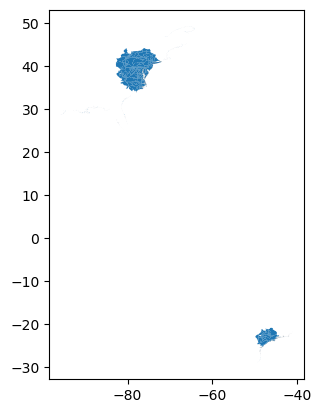

In [154]:
df_points_aq.plot()

In [155]:
df_states= df[df["Select_By"] == "state"]
print("There are {} states".format(len(df_states)))

There are 1 states


In [156]:
#match aq to input
df_aq = df_aq.rename(columns={"gid_0": "iso_code", "name_0": "Country", "name_1": "State"})

In [157]:
df_states_aq = df_states.merge(df_aq, on = ["iso_code", "Country", "State"], how = 'left')
df_states_aq


,UniqueID,Business Unit,Latitude,Longitude,Radius,Radius Units,Country,iso_code,State,Commodity,commodity_code,Total Volume,Volume Units,Irrigation,Select_By,string_id,aq30_id,Shape_Leng,string_id_1,aq30_id_1,pfaf_id,gid_1,aqid,area_km2,bws_raw,bws_score,bws_cat,bws_label,bwd_raw,bwd_score,bwd_cat,bwd_label,iav_raw,iav_score,iav_cat,iav_label,sev_raw,sev_score,sev_cat,sev_label,cep_raw,cep_score,cep_cat,cep_label,geometry,aq_geometry
0,2,North America Snacks,NaN,NaN,NaN,NaN,United States,USA,California,Maize,MAIZ,500,NaN,Irrigated,state,772000-USA.5_1-1441,57856.0,4.466032,772000-USA.5_1-1441,57856,772000,USA.5_1,1441,1967.621911,9999.000000,5.000000,4.0,Extremely High (>80%),9999.000000,5.000000,4.0,Extremely High (>75%),1.020511,4.082043,4.0,Extremely High (>1.00),0.611942,1.835826,1.0,Low - Medium (0.33-0.66),-0.078259,1.984348,1.0,Low - Medium (-5 to 0),"MULTIPOLYGON (((-116.53386 33.29479, -116.5436...","MULTIPOLYGON (((-116.53386 33.29479, -116.5436..."
1,2,North America Snacks,NaN,NaN,NaN,NaN,United States,USA,California,Maize,MAIZ,500,NaN,Irrigated,state,772000-USA.5_1-1547,57857.0,4.898886,772000-USA.5_1-1547,57857,772000,USA.5_1,1547,9392.758235,9999.000000,5.000000,4.0,Extremely High (>80%),9999.000000,5.000000,4.0,Extremely High (>75%),1.020511,4.082043,4.0,Extremely High (>1.00),0.611942,1.835826,1.0,Low - Medium (0.33-0.66),-0.078259,1.984348,1.0,Low - Medium (-5 to 0),"MULTIPOLYGON (((-116.70417 34.15833, -116.6934...","MULTIPOLYGON (((-116.70417 34.15833, -116.6934..."
2,2,North America Snacks,NaN,NaN,NaN,NaN,United States,USA,California,Maize,MAIZ,500,NaN,Irrigated,state,772000-USA.5_1-1587,57858.0,3.939521,772000-USA.5_1-1587,57858,772000,USA.5_1,1587,7168.333911,9999.000000,5.000000,4.0,Extremely High (>80%),9999.000000,5.000000,4.0,Extremely High (>75%),1.020511,4.082043,4.0,Extremely High (>1.00),0.611942,1.835826,1.0,Low - Medium (0.33-0.66),-0.078259,1.984348,1.0,Low - Medium (-5 to 0),"MULTIPOLYGON (((-115.33333 33.47083, -115.3333...","MULTIPOLYGON (((-115.33333 33.47083, -115.3333..."
3,2,North America Snacks,NaN,NaN,NaN,NaN,United States,USA,California,Maize,MAIZ,500,NaN,Irrigated,state,772100-USA.5_1-1587,57865.0,1.360184,772100-USA.5_1-1587,57865,772100,USA.5_1,1587,449.935192,1.059235,4.404950,4.0,Extremely High (>80%),0.469018,2.876070,2.0,Medium - High (25-50%),0.802877,3.211509,3.0,High (0.75-1.00),0.120770,0.362311,0.0,Low (<0.33),-0.111965,1.977607,1.0,Low - Medium (-5 to 0),"MULTIPOLYGON (((-114.73333 32.96250, -114.7267...","MULTIPOLYGON (((-114.73333 32.96250, -114.7267..."
4,2,North America Snacks,NaN,NaN,NaN,NaN,United States,USA,California,Maize,MAIZ,500,NaN,Irrigated,state,772310-USA.5_1-1547,57946.0,0.163390,772310-USA.5_1-1547,57946,772310,USA.5_1,1547,7.013618,0.272719,2.447413,2.0,Medium - High (20-40%),0.156283,1.531417,1.0,Low - Medium (5-25%),0.713175,2.852701,2.0,Medium - High (0.50-0.75),0.154294,0.462881,0.0,Low (<0.33),-0.119384,1.976123,1.0,Low - Medium (-5 to 0),"MULTIPOLYGON (((-114.78796 34.33345, -114.8614...","MULTIPOLYGON (((-114.78796 34.33345, -114.8614..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,2,North America Snacks,NaN,NaN,NaN,NaN,United States,USA,California,Maize,MAIZ,500,NaN,Irrigated,state,781001-USA.5_1-None,58586.0,0.151073,781001-USA.5_1-None,58586,781001,USA.5_1,-9999,9.861869,0.006085,0.000000,0.0,Low (<10%),0.001867,0.037330,0.0,Low (<5%),0.337946,1.351786,1.0,Low - Medium (0.25-0.50),0.354739,1.064218,1.0,Low - Medium (0.33-0.66),-13.811475,0.962603,0.0,Low (<-5),"MULTIPOLYGON (((-124.17703 41.95894, -124.1840...","MULTIPOLYGON (((-124.17703 41.95894, -124.1840..."
209,2,North America Snacks,NaN,NaN,NaN,NaN,United States,USA,California,Maize,MAIZ,500,NaN,Irrigated,state,781002-USA.5_1-725,58591.0,1.722776,781002-USA.5_1-725,58591,781002,USA.5_1,725,381.843377,0.063482,0.344425,0.0,Low (<10%),0.030697,0

In [158]:
df_countries= df[df["Select_By"] == "country"]
print("There are {} Countries".format(len(df_countries)))

There are 1 Countries


In [159]:
df_countries_aq = df_countries.merge(df_aq, on = ["iso_code", "Country"], how = 'left')
df_countries_aq
admin_aq = pd.concat([df_states_aq, df_countries_aq, df_points_aq], ignore_index=True)
admin_aq

,UniqueID,Business Unit,Latitude,Longitude,Radius,Radius Units,Country,iso_code,State,Commodity,commodity_code,Total Volume,Volume Units,Irrigation,Select_By,string_id,aq30_id,Shape_Leng,string_id_1,aq30_id_1,pfaf_id,gid_1,aqid,area_km2,bws_raw,bws_score,bws_cat,bws_label,bwd_raw,bwd_score,bwd_cat,bwd_label,iav_raw,iav_score,iav_cat,iav_label,sev_raw,sev_score,sev_cat,sev_label,cep_raw,cep_score,cep_cat,cep_label,geometry,aq_geometry,State_x,State_y,Radius_x,Country_left,iso_code_left,State_left,Radius_y,index_right,iso_code_right,Country_right,State_right
0,2,North America Snacks,NaN,NaN,NaN,NaN,United States,USA,California,Maize,MAIZ,500,NaN,Irrigated,state,772000-USA.5_1-1441,57856.0,4.466032,772000-USA.5_1-1441,57856,772000,USA.5_1,1441,1967.621911,9999.000000,5.000000,4.0,Extremely High (>80%),9999.000000,5.000000,4.0,Extremely High (>75%),1.020511,4.082043,4.0,Extremely High (>1.00),0.611942,1.835826,1.0,Low - Medium (0.33-0.66),-0.078259,1.984348,1.0,Low - Medium (-5 to 0),"MULTIPOLYGON (((-116.53386 33.29479, -116.5436...","MULTIPOLYGON (((-116.53386 33.29479, -116.5436...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,North America Snacks,NaN,NaN,NaN,NaN,United States,USA,California,Maize,MAIZ,500,NaN,Irrigated,state,772000-USA.5_1-1547,57857.0,4.898886,772000-USA.5_1-1547,57857,772000,USA.5_1,1547,9392.758235,9999.000000,5.000000,4.0,Extremely High (>80%),9999.000000,5.000000,4.0,Extremely High (>75%),1.020511,4.082043,4.0,Extremely High (>1.00),0.611942,1.835826,1.0,Low - Medium (0.33-0.66),-0.078259,1.984348,1.0,Low - Medium (-5 to 0),"MULTIPOLYGON (((-116.70417 34.15833, -116.6934...","MULTIPOLYGON (((-116.70417 34.15833, -116.6934...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,North America Snacks,NaN,NaN,NaN,NaN,United States,USA,California,Maize,MAIZ,500,NaN,Irrigated,state,772000-USA.5_1-1587,57858.0,3.939521,772000-USA.5_1-1587,57858,772000,USA.5_1,1587,7168.333911,9999.000000,5.000000,4.0,Extremely High (>80%),9999.000000,5.000000,4.0,Extremely High (>75%),1.020511,4.082043,4.0,Extremely High (>1.00),0.611942,1.835826,1.0,Low - Medium (0.33-0.66),-0.078259,1.984348,1.0,Low - Medium (-5 to 0),"MULTIPOLYGON (((-115.33333 33.47083, -115.3333...","MULTIPOLYGON (((-115.33333 33.47083, -115.3333...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,North America Snacks,NaN,NaN,NaN,NaN,United States,USA,California,Maize,MAIZ,500,NaN,Irrigated,state,772100-USA.5_1-1587,57865.0,1.360184,772100-USA.5_1-1587,57865,772100,USA.5_1,1587,449.935192,1.059235,4.404950,4.0,Extremely High (>80%),0.469018,2.876070,2.0,Medium - High (25-50%),0.802877,3.211509,3.0,High (0.75-1.00),0.120770,0.362311,0.0,Low (<0.33),-0.111965,1.977607,1.0,Low - Medium (-5 to 0),"MULTIPOLYGON (((-114.73333 32.96250, -114.7267...","MULTIPOLYGON (((-114.73333 32.96250, -114.7267...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2,North America Snacks,NaN,NaN,NaN,NaN,United States,USA,California,Maize,MAIZ,500,NaN,Irrigated,state,772310-USA.5_1-1547,57946.0,0.163390,772310-USA.5_1-1547,57946,772310,USA.5_1,1547,7.013618,0.272719,2.447413,2.0,Medium - High (20-40%),0.156283,1.531417,1.0,Low - Medium (5-25%),0.713175,2.852701,2.0,Medium - High (0.50-0.75),0.154294,0.462881,0.0,Low (<0.33),-0.119384,1.976123,1.0,Low - Medium (-5 to 0),"MULTIPOLYGON (((-114.78796 34.33345, -114.8614...","MULTIPOLYGON (((-114.78796 34.33345, -114.8614...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1711,1,EU Snacks,-23.568232,-46.693983,NaN,kilometer,NaN,NaN,NaN,Wheat,WHEA,100,kilograms,Both,point,642980-BRA.13_1-2485,49541.0,9.867667,642980-BRA.13_1-2485,49541,642980,BRA.13_1,2485,24242.151656,0.026403,0.000000,0.0,Low (<10%),0.009042,0.180837,0.0,Low (<5%),0.281721,1.126885,1.0,Low - Medium (0.25-0.50),0.292739,0.878218,0.0,Low (<0.33),0.0

In [160]:
admin_aq = gpd.GeoDataFrame(admin_aq, crs="EPSG:4326")

basins = admin_aq.dissolve(by=['UniqueID','pfaf_id','gid_1'])
basins = basins.reset_index()
basins= basins[['UniqueID',	'pfaf_id', 'gid_1', 'geometry', 'Business Unit',	'Latitude', 'Longitude', 'Radius',	'Radius Units', 'Country', 'iso_code',
            'State','Commodity', 'commodity_code', 'Total Volume', 'Volume Units','Irrigation', 'bws_raw','bws_score', 'bws_cat', 'bws_label']]
#Clean up basins
#remove pfafid = -9999
basins = basins[basins['pfaf_id'] != -9999]
basins = basins[basins['gid_1'] != -9999]
basins = basins.dropna(subset=['pfaf_id'])
basins
print("There are {} basins-stated found".format(len(basins)))

There are 887 basins-stated found


In [161]:
basins.to_file('data_test.geojson')

In [162]:
#merge SBTN and production to data
basins = basins.merge(SBTN, on = ['pfaf_id'])
basins = basins.merge(prod, on = ['pfaf_id','gid_1','commodity_code','Irrigation'], how = 'left')
basins

,UniqueID,pfaf_id,gid_1,geometry,Business Unit,Latitude,Longitude,Radius,Radius Units,Country,iso_code,State,Commodity,commodity_code,Total Volume,Volume Units,Irrigation,bws_raw,bws_score,bws_cat,bws_label,Unnamed: 0_x,SBTN_quant_max,SBTN_qual_max,Unnamed: 0_y,Basin Production
0,0,725530,USA.33_1,"POLYGON ((-76.15478 44.19304, -76.15869 44.185...",North America Snacks,38.898992,-77.007986,NaN,kilometer,None,None,None,Maize,MAIZ,450,metric tons,Rainfed,0.055757,0.157215,0.0,Low (<10%),11847,1.0,4.0,1504178.0,85065.890625
1,0,725540,USA.33_1,"POLYGON ((-77.50417 42.92083, -77.49680 42.925...",North America Snacks,38.898992,-77.007986,NaN,kilometer,None,None,None,Maize,MAIZ,450,metric tons,Rainfed,0.001699,0.000000,0.0,Low (<10%),11848,1.0,4.0,1504180.0,651879.562500
2,0,725551,USA.33_1,"POLYGON ((-77.50417 42.92083, -77.51492 42.921...",North America Snacks,38.898992,-77.007986,NaN,kilometer,None,None,None,Maize,MAIZ,450,metric tons,Rainfed,0.003916,0.000000,0.0,Low (<10%),11849,1.0,4.0,1504182.0,51400.156250
3,0,725552,USA.33_1,"POLYGON ((-77.47096 43.57319, -77.46727 43.564...",North America Snacks,38.898992,-77.007986,NaN,kilometer,None,None,None,Maize,MAIZ,450,metric tons,Rainfed,0.001166,0.000000,0.0,Low (<10%),11857,1.0,4.0,1504183.0,387253.375000
4,0,725552,USA.39_1,"POLYGON ((-77.73951 41.88812, -77.76049 41.878...",North America Snacks,38.898992,-77.007986,NaN,kilometer,None,None,None,Maize,MAIZ,450,metric tons,Rainfed,0.001166,0.000000,0.0,Low (<10%),11857,1.0,4.0,1504184.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
882,3,664027,ARG.10_1,"POLYGON ((-66.60417 -22.84167, -66.61042 -22.8...",South America Snacks,NaN,NaN,NaN,None,Argentina,ARG,None,Soybean,SOYB,1000,metric tons,All,0.000840,0.000000,0.0,Low (<10%),14840,1.0,2.0,3587287.0,0.000000
883,3,664027,ARG.17_1,"MULTIPOLYGON (((-66.46722 -24.19793, -66.47445...",South America Snacks,NaN,NaN,NaN,None,Argentina,ARG,None,Soybean,SOYB,1000,metric tons,All,0.000840,0.000000,0.0,Low (<10%),14840,1.0,2.0,3587288.0,0.000000
884,3,664028,ARG.10_1,"POLYGON ((-67.01734 -22.64764, -67.01582 -22.6...",South America Snacks,NaN,NaN,NaN,None,Argentina,ARG,None,Soybean,SOYB,1000,metric tons,All,1.000000,5.000000,-1.0,Arid and Low Water Use,14873,5.0,2.0,3587291.0,0.000000
885,3,664030,ARG.17_1,"MULTIPOLYGON (((-68.53389 -24.70860, -68.52695...",South America Snacks,NaN,NaN,NaN,None,Argentina,ARG,None,Soybean,SOYB,1000,metric tons,All,1.000000,5.000000,-1.0,Arid and Low Water Use,14819,5.0,3.0,3587294.0,0.000000


In [163]:
basins.to_file('basin_state_check.shp')

In [164]:
# calculate proportion sourced from each basin
pro_per_entry = basins.groupby('UniqueID').sum('Basin Production')
pro_per_entry  = pro_per_entry.reset_index()
pro_per_entry = pro_per_entry.rename(columns={'Basin Production':"summed production"})
pro_per_entry = pro_per_entry[['UniqueID',"summed production"]]
pro_per_entry

,UniqueID,summed production
0,0,1.585031e+07
1,1,0.000000e+00
2,2,4.701827e+05
3,3,5.009800e+07


In [165]:
basins = basins.merge(pro_per_entry, on = 'UniqueID')
basins['Production Sourced From Basin'] = basins['Total Volume']*(basins['Basin Production']/basins['summed production'])
basins

,UniqueID,pfaf_id,gid_1,geometry,Business Unit,Latitude,Longitude,Radius,Radius Units,Country,iso_code,State,Commodity,commodity_code,Total Volume,Volume Units,Irrigation,bws_raw,bws_score,bws_cat,bws_label,Unnamed: 0_x,SBTN_quant_max,SBTN_qual_max,Unnamed: 0_y,Basin Production,summed production,Production Sourced From Basin
0,0,725530,USA.33_1,"POLYGON ((-76.15478 44.19304, -76.15869 44.185...",North America Snacks,38.898992,-77.007986,NaN,kilometer,None,None,None,Maize,MAIZ,450,metric tons,Rainfed,0.055757,0.157215,0.0,Low (<10%),11847,1.0,4.0,1504178.0,85065.890625,1.585031e+07,2.415072
1,0,725540,USA.33_1,"POLYGON ((-77.50417 42.92083, -77.49680 42.925...",North America Snacks,38.898992,-77.007986,NaN,kilometer,None,None,None,Maize,MAIZ,450,metric tons,Rainfed,0.001699,0.000000,0.0,Low (<10%),11848,1.0,4.0,1504180.0,651879.562500,1.585031e+07,18.507258
2,0,725551,USA.33_1,"POLYGON ((-77.50417 42.92083, -77.51492 42.921...",North America Snacks,38.898992,-77.007986,NaN,kilometer,None,None,None,Maize,MAIZ,450,metric tons,Rainfed,0.003916,0.000000,0.0,Low (<10%),11849,1.0,4.0,1504182.0,51400.156250,1.585031e+07,1.459282
3,0,725552,USA.33_1,"POLYGON ((-77.47096 43.57319, -77.46727 43.564...",North America Snacks,38.898992,-77.007986,NaN,kilometer,None,None,None,Maize,MAIZ,450,metric tons,Rainfed,0.001166,0.000000,0.0,Low (<10%),11857,1.0,4.0,1504183.0,387253.375000,1.585031e+07,10.994359
4,0,725552,USA.39_1,"POLYGON ((-77.73951 41.88812, -77.76049 41.878...",North America Snacks,38.898992,-77.007986,NaN,kilometer,None,None,None,Maize,MAIZ,450,metric tons,Rainfed,0.001166,0.000000,0.0,Low (<10%),11857,1.0,4.0,1504184.0,0.000000,1.585031e+07,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
882,3,664027,ARG.10_1,"POLYGON ((-66.60417 -22.84167, -66.61042 -22.8...",South America Snacks,NaN,NaN,NaN,None,Argentina,ARG,None,Soybean,SOYB,1000,metric tons,All,0.000840,0.000000,0.0,Low (<10%),14840,1.0,2.0,3587287.0,0.000000,5.009800e+07,0.000000
883,3,664027,ARG.17_1,"MULTIPOLYGON (((-66.46722 -24.19793, -66.47445...",South America Snacks,NaN,NaN,NaN,None,Argentina,ARG,None,Soybean,SOYB,1000,metric tons,All,0.000840,0.000000,0.0,Low (<10%),14840,1.0,2.0,3587288.0,0.000000,5.009800e+07,0.000000
884,3,664028,ARG.10_1,"POLYGON ((-67.01734 -22.64764, -67.01582 -22.6...",South America Snacks,NaN,NaN,NaN,None,Argentina,ARG,None,Soybean,SOYB,1000,metric tons,All,1.000000,5.000000,-1.0,Arid and Low Water Use,14873,5.0,2.0,3587291.0,0.000000,5.009800e+07,0.000000
885,3,664030,ARG.17_1,"MULTIPOLYGON (((-68.53389 -24.70860, -68.52695...",South America Snacks,NaN,NaN,NaN,None,Argentina,ARG,None,Soybean,SOYB,1000,metric tons,All,1.000000,5.000000,-1.0,Arid and Low Water Use,14819,5.0,3.0,3587294.0,0.000000,5.009800e+07,0.000000


In [166]:
Basin_results = basins[basins['Production Sourced From Basin'].notna()]
Basin_results = basins[basins['Production Sourced From Basin']!= 0]
Basin_results = Basin_results.drop(columns={'Unnamed: 0_x', 'Unnamed: 0_y','commodity_code','Basin Production', 'summed production'})
Basin_results

,UniqueID,pfaf_id,gid_1,geometry,Business Unit,Latitude,Longitude,Radius,Radius Units,Country,iso_code,State,Commodity,Total Volume,Volume Units,Irrigation,bws_raw,bws_score,bws_cat,bws_label,SBTN_quant_max,SBTN_qual_max,Production Sourced From Basin
0,0,725530,USA.33_1,"POLYGON ((-76.15478 44.19304, -76.15869 44.185...",North America Snacks,38.898992,-77.007986,NaN,kilometer,None,None,None,Maize,450,metric tons,Rainfed,0.055757,0.157215,0.0,Low (<10%),1.0,4.0,2.415072
1,0,725540,USA.33_1,"POLYGON ((-77.50417 42.92083, -77.49680 42.925...",North America Snacks,38.898992,-77.007986,NaN,kilometer,None,None,None,Maize,450,metric tons,Rainfed,0.001699,0.000000,0.0,Low (<10%),1.0,4.0,18.507258
2,0,725551,USA.33_1,"POLYGON ((-77.50417 42.92083, -77.51492 42.921...",North America Snacks,38.898992,-77.007986,NaN,kilometer,None,None,None,Maize,450,metric tons,Rainfed,0.003916,0.000000,0.0,Low (<10%),1.0,4.0,1.459282
3,0,725552,USA.33_1,"POLYGON ((-77.47096 43.57319, -77.46727 43.564...",North America Snacks,38.898992,-77.007986,NaN,kilometer,None,None,None,Maize,450,metric tons,Rainfed,0.001166,0.000000,0.0,Low (<10%),1.0,4.0,10.994359
5,0,725553,USA.33_1,"POLYGON ((-77.54976 43.56355, -77.54933 43.559...",North America Snacks,38.898992,-77.007986,NaN,kilometer,None,None,None,Maize,450,metric tons,Rainfed,0.528149,3.400944,3.0,High (40-80%),4.0,4.0,8.247398
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646,3,652501,ARG.19_1,"POLYGON ((-66.31312 -35.46883, -66.31596 -35.4...",South America Snacks,NaN,NaN,NaN,None,Argentina,ARG,None,Soybean,1000,metric tons,All,0.322304,2.688424,2.0,Medium - High (20-40%),3.0,3.0,0.002292
653,3,652505,ARG.19_1,"POLYGON ((-66.44943 -34.23971, -66.44640 -34.2...",South America Snacks,NaN,NaN,NaN,None,Argentina,ARG,None,Soybean,1000,metric tons,All,0.001064,0.000000,0.0,Low (<10%),3.0,3.0,0.003601
656,3,652507,ARG.19_1,"POLYGON ((-66.90777 -33.36862, -66.90890 -33.3...",South America Snacks,NaN,NaN,NaN,None,Argentina,ARG,None,Soybean,1000,metric tons,All,0.515473,3.365898,3.0,High (40-80%),4.0,3.0,0.000455
712,3,653100,ARG.1_1,"MULTIPOLYGON (((-62.23361 -40.68361, -62.23183...",South America Snacks,NaN,NaN,NaN,None,Argentina,ARG,None,Soybean,1000,metric tons,All,1.000000,5.000000,-1.0,Arid and Low Water Use,5.0,3.0,0.081291
